<!-- DEA Notebook Header -->
<div style="font-family:'Segoe UI',Roboto,sans-serif; line-height:1.6; color:CanvasText; padding:32px;">

<img src="https://raw.githubusercontent.com/GeoscienceAustralia/dea-notebooks/stable/Supplementary_data/dea_logo_wide.jpg" alt="DEA Notebooks logo" style="width:86.5%;">

<h1>Using "load_ard" to load and cloud mask Landsat and Sentinel-2</h1>

<p>
🔎 Visit <a href="https://knowledge.dea.ga.gov.au">DEA's Knowledge Hub</a> for detailed technical information about the datasets and concepts used in this notebook.
</p>

<p>
<span style="display:inline-block; font-size:12px; background:rgba(59,130,246,0.15); border-radius:12px; padding:3px 10px; margin-right:6px;">🟡 Intermediate</span>
<span style="display:inline-block; font-size:12px; background:rgba(16,185,129,0.15); border-radius:12px; padding:3px 10px; margin-right:6px;">⚡ Runtime: <10 min</span>
<span style="display:inline-block; font-size:12px; background:rgba(107,114,128,0.15); border-radius:12px; padding:3px 10px; margin-right:6px;">🗓️ Updated: 2025-12</span>
</p>

<!-- Products - REQUIRED -->
<div style="margin-bottom:12px; padding:12px; background:rgba(59,130,246,0.08); border:1px solid rgb(59,130,246); border-radius:8px; max-width:85%;">
<b>📦 Products used</b><br>

<a href="https://knowledge.dea.ga.gov.au/data/product/dea-surface-reflectance-landsat-5-tm/?tab=specifications">ga_ls5t_ard_3</a>,
<a href="https://knowledge.dea.ga.gov.au/data/product/dea-surface-reflectance-landsat-7-etm/?tab=specifications">ga_ls7e_ard_3</a>,
<a href="https://knowledge.dea.ga.gov.au/data/product/dea-surface-reflectance-landsat-8-oli-tirs/?tab=specifications">ga_ls8c_ard_3</a>,
<a href="https://knowledge.dea.ga.gov.au/data/product/dea-surface-reflectance-landsat-9-oli-tirs/?tab=specifications">ga_ls9c_ard_3</a>,
<a href="https://knowledge.dea.ga.gov.au/data/product/dea-surface-reflectance-sentinel-2a-msi/?tab=specifications">ga_s2am_ard_3</a>,
<a href="https://knowledge.dea.ga.gov.au/data/product/dea-surface-reflectance-sentinel-2b-msi/?tab=specifications">ga_s2bm_ard_3</a>,
<a href="https://knowledge.dea.ga.gov.au/data/product/dea-surface-reflectance-sentinel-2c-msi/?tab=specifications">ga_s2cm_ard_3</a>

</div>

<!-- How to run - REQUIRED -->
<div style="margin-bottom:12px; padding:12px; background:rgba(16,185,129,0.1); border:1px solid rgb(16,185,129); border-radius:8px; max-width:85%;">
<b>🚀 How you can run this notebook</b><br>

- <b>DEA Sandbox:</b> Eligible users can sign up for the <a href="https://sandbox.dea.ga.gov.au/">DEA Sandbox</a> that provides free compute and a managed Python environment.

- <b>Personal computer:</b> This notebook loads DEA data using <code>odc-stac</code>. Data streams via the internet, so can be run locally after installing the required <a href="https://pypi.org/project/dea-tools/">DEA Tools</a> Python package, e.g. <code>pip install dea-tools[notebooks]</code>.

- <b>Run this notebook online:</b> Click on the badge below to launch a GitHub Codespaces instance to run the notebook from your browser. See this <a href="">wiki page</a> for more information.

  <a href="https://codespaces.new/GeoscienceAustralia/dea-notebooks/tree/template?quickstart=1" target="_blank">
    <img src="https://img.shields.io/badge/Codespaces-Open-blue?logo=github" alt="Open in GitHub Codespaces" style="height:25px;">
  </a>
</div>
</div>


## Description
This notebook demonstrates how to use the `load_ard` function to import a time series of cloud-free observations from multiple Landsat or Sentinel-2 satellite products.
The function can automatically apply pixel quality masking (e.g. cloud masking) to the input data and return all available data from multiple sensors as a single combined `xarray.Dataset`.

Optionally, the function can be used to return only observations that contain a minimum proportion of good quality, non-cloudy or shadowed pixels. 
This can be used to extract visually appealing and analysis-ready time series of observations that are not affected by cloud.

The function supports the following Digital Earth Australia products:

* Geoscience Australia Landsat Collection 3: `ga_ls5t_ard_3`, `ga_ls7e_ard_3`, `ga_ls8c_ard_3`, `ga_ls9c_ard_3`
* Geoscience Australia Sentinel-2 Collection 3: `ga_s2am_ard_3`, `ga_s2bm_ard_3`, `ga_s2cm_ard_3`


This notebook demonstrates how to use `load_ard` to:

1. [Load and combine data from multiple Landsat sensors into a single xarray.Dataset](#Loading-and-combining-data-from-multiple-Landsat-sensors)
2. [Mask out clouds using the "Fmask" cloud mask](#Cloud-masking-using-mask_pixel_quality)
3. [Filter resulting data to keep only cloud-free observations](#Filtering-to-non-cloudy-observations-using-min_gooddata)
4. [Clean and dilate a cloud mask using morphological filtering](#Dilating-and-cleaning-cloud-masks-using-morphological-processing)
5. [Discard Landsat 7 SLC-off failure data](#Discarding-Landsat-7-SLC-off-failure-data)
6. [Load and combine from multiple Sentinel-2 sensors into a single xarray.Dataset](#Loading-and-combining-data-from-multiple-Sentinel-2-sensors)
7. [Mask out clouds using the "s2cloudless" cloud mask](#Cloud-masking-with-s2cloudless)
8. [Advanced: Filter data before loading using metadata](#Filtering-data)
9. [Advanced: Lazily load data using Dask](#Lazy-loading-with-Dask)

***

## Setup

### Load packages

Import Python packages that are used for the analysis.


In [1]:
import odc.stac
import matplotlib.pyplot as plt
import pystac_client

from dea_tools.dask import create_local_dask_cluster
from dea_tools.datahandling import load_ard
from dea_tools.plotting import rgb

### Connect to DEA's STAC API

This allows us to search for data using DEA's STAC API (refer to the [SpatioTemporal Asset Catalogue guide](https://knowledge.dea.ga.gov.au/guides/setup/gis/stac/) for details).

To load data, we must also configure access to DEA's Amazon S3 buckets using `odc.stac.configure_s3_access`.
If launching a Dask client (e.g. `dea_tools.dask.create_local_dask_cluster()`), this is done automatically.

In [2]:
# Configure data access
odc.stac.configure_s3_access(cloud_defaults=True, aws_unsigned=True)

# Connect to STAC API
catalog = pystac_client.Client.open("https://explorer.dea.ga.gov.au/stac")

## Analysis

### Loading and combining data from multiple Landsat sensors
The `load_ard` function can be used to load a single, combined timeseries of cloud-masked data from multiple Digital Earth Australia products or satellite sensors. 
By default, `load_ard` searches and loads data using STAC metadata and the `odc-stac` Python package.
You can pass a set of spatio-temporal query parameters (e.g. `lon`, `lat`, `datetime`) and load parameters (`bands`, `crs`, `resolution`, `groupby` etc) directly into the function ([see the odc.stac.load documentation for all possible options](https://datacube-core.readthedocs.io/en/latest/api/indexed-data/generate/datacube.Datacube.load.html)).

In the examples below, we load three Landsat bands (red, green and blue) from four Landsat products (Landsat 5, 7, 8 and 9):

In [3]:
# Load available data
ds = load_ard(
    dc=catalog,
    products=["ga_ls5t_ard_3", "ga_ls7e_ard_3", "ga_ls8c_ard_3", "ga_ls9c_ard_3"],
    bands=["nbart_green", "nbart_red", "nbart_blue"],
    lon=(149.06, 149.17),
    lat=(-35.27, -35.32),
    datetime="2021-06-27/2021-08-13",
    groupby="solar_day",
)

# Print output data
ds

Loading data with STAC
Searching STAC for ga_ls5t_ard_3, ga_ls7e_ard_3, ga_ls8c_ard_3, ga_ls9c_ard_3 data
Applying fmask pixel quality/cloud mask
Loading 12 time steps


<xarray.Dataset> Size: 9MB
Dimensions:      (time: 12, y: 193, x: 338)
Coordinates:
  * y            (y) float64 2kB -3.905e+06 -3.905e+06 ... -3.911e+06 -3.911e+06
  * x            (x) float64 3kB 6.873e+05 6.873e+05 ... 6.974e+05 6.974e+05
    spatial_ref  int32 4B 32655
  * time         (time) datetime64[ns] 96B 2021-06-27T23:50:11.179302 ... 202...
Data variables:
    nbart_green  (time, y, x) float32 3MB 1.452e+03 1.591e+03 ... nan nan
    nbart_red    (time, y, x) float32 3MB 1.441e+03 1.579e+03 ... nan nan
    nbart_blue   (time, y, x) float32 3MB 1.189e+03 1.312e+03 ... nan nan

### Query dictionary syntax
Often it can be useful to keep our query parameters (e.g. the area and time we want to search) separate to allow us to easily run our code on different locations or timesteps in the future.
The following example demonstrates how spatiotemporal query parameters can be stored in a `query` dictionary and then passed to `load_ard`:

In [4]:
# Create re-usable query parameters
query = {
    "lon": (149.06, 149.17),
    "lat": (-35.27, -35.32),
    "datetime": "2021-06-27/2021-08-13",
}

# Load available data
ds = load_ard(
    dc=catalog,
    products=["ga_ls5t_ard_3", "ga_ls7e_ard_3", "ga_ls8c_ard_3", "ga_ls9c_ard_3"],
    bands=["nbart_green", "nbart_red", "nbart_blue"],
    groupby="solar_day",
    **query,
)

# Print output data
ds

Loading data with STAC
Searching STAC for ga_ls5t_ard_3, ga_ls7e_ard_3, ga_ls8c_ard_3, ga_ls9c_ard_3 data
Applying fmask pixel quality/cloud mask
Loading 12 time steps


<xarray.Dataset> Size: 9MB
Dimensions:      (time: 12, y: 193, x: 338)
Coordinates:
  * y            (y) float64 2kB -3.905e+06 -3.905e+06 ... -3.911e+06 -3.911e+06
  * x            (x) float64 3kB 6.873e+05 6.873e+05 ... 6.974e+05 6.974e+05
    spatial_ref  int32 4B 32655
  * time         (time) datetime64[ns] 96B 2021-06-27T23:50:11.179302 ... 202...
Data variables:
    nbart_green  (time, y, x) float32 3MB 1.452e+03 1.591e+03 ... nan nan
    nbart_red    (time, y, x) float32 3MB 1.441e+03 1.579e+03 ... nan nan
    nbart_blue   (time, y, x) float32 3MB 1.189e+03 1.312e+03 ... nan nan

### Cloud masking using `mask_pixel_quality`
By plotting a time slice from the data we loaded above, you can see an area of white pixels where clouds, shadows or invalid data have been masked out and set to `NaN`:

/env/lib/python3.10/site-packages/odc/geo/_rgba.py:55: RuntimeWarning: invalid value encountered in cast
  return x.astype("uint8")


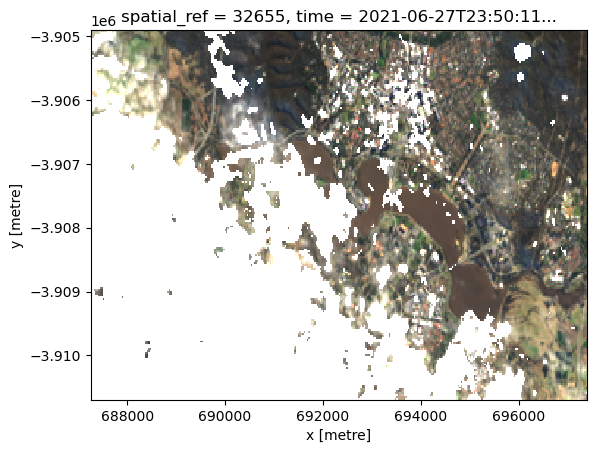

In [5]:
# Plot single cloud-masked observation
ds.isel(time=0).odc.to_rgba(vmin=0, vmax=2000).plot.imshow()

By default, `load_ard` applies a pixel quality mask to loaded data using the `fmask` (Function of Mask) cloud mask (this can be changed using the `cloud_mask` parameter; [see Cloud masking with s2cloudless below](#Cloud-masking-with-s2cloudless)). 
The default mask is created based on `fmask` categories `['valid', 'snow', 'water']` which will preserve non-cloudy or shadowed land, snow and water pixels, and set all invalid, cloudy or shadowy pixels to `NaN`. 
This can be customised using the `fmask_categories` parameter.
To deactive cloud masking completely, set `mask_pixel_quality=False`:

Loading data with STAC
Searching STAC for ga_ls5t_ard_3, ga_ls7e_ard_3, ga_ls8c_ard_3, ga_ls9c_ard_3 data
Loading 12 time steps


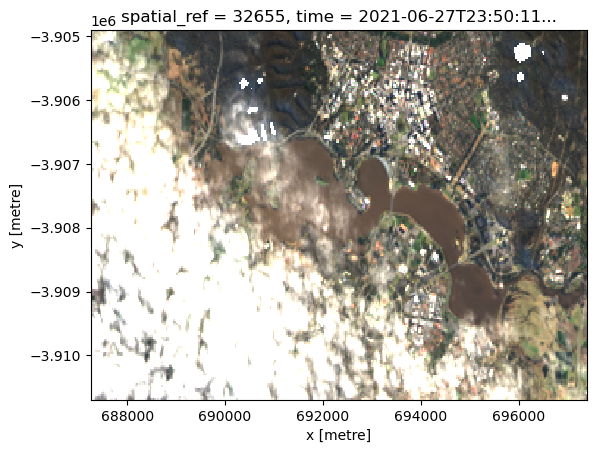

In [6]:
# Load available data with cloud masking deactivated
ds_cloudy = load_ard(
    dc=catalog,
    products=["ga_ls5t_ard_3", "ga_ls7e_ard_3", "ga_ls8c_ard_3", "ga_ls9c_ard_3"],
    bands=["nbart_green", "nbart_red", "nbart_blue"],
    groupby="solar_day",
    mask_pixel_quality=False,
    **query,
)

# Plot single observation
ds_cloudy.isel(time=0).odc.to_rgba(vmin=0, vmax=2000).plot.imshow()

#### Filtering to non-cloudy observations using `min_gooddata`
In addition to masking out cloud, `load_ard` allows you to discard any satellite observation that contains less than a minimum proportion of good quality (e.g. non-cloudy) pixels.
This can be used to obtain a time series of only clear, cloud-free observations.

To discard all observations with less than `X`% good quality pixels, use the `min_gooddata` parameter. 
For example, `min_gooddata=0.90` will return only observations where less than 10% of pixels contain cloud, cloud shadow or other invalid data, resulting in a smaller number of clear, cloud free images being returned by the function:

Loading data with STAC
Searching STAC for ga_ls5t_ard_3, ga_ls7e_ard_3, ga_ls8c_ard_3, ga_ls9c_ard_3 data
Counting good quality pixels for each time step using fmask
Filtering to 1 out of 12 time steps with at least 90.0% good quality pixels
Loading 1 time steps


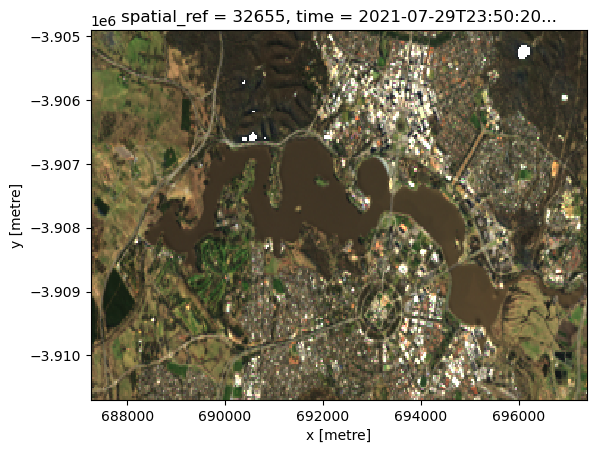

In [7]:
# Load available data filtered to 90% clear observations
ds_noclouds = load_ard(
    dc=catalog,
    products=["ga_ls5t_ard_3", "ga_ls7e_ard_3", "ga_ls8c_ard_3", "ga_ls9c_ard_3"],
    bands=["nbart_green", "nbart_red", "nbart_blue"],
    groupby="solar_day",
    mask_pixel_quality=False,
    min_gooddata=0.90,
    **query,
)

# Plot single observation
ds_noclouds.isel(time=0).odc.to_rgba(vmin=0, vmax=2000).plot.imshow()

#### Dilating and cleaning cloud masks using morphological processing

There are significant known limitations to the cloud masking algorithms employed by Sentinel-2 and Landsat. 
For example, bright objects like buildings and coastlines are commonly mistaken for cloud. 
We can improve on the false positives detected by Landsat and Sentinel-2's pixel quality mask by applying binary morphological image processing techniques (e.g. [binary_closing](https://docs.scipy.org/doc/scipy-0.15.1/reference/generated/scipy.ndimage.morphology.binary_closing.html#scipy.ndimage.morphology.binary_closing), [binary_erosion](https://docs.scipy.org/doc/scipy-0.15.1/reference/generated/scipy.ndimage.morphology.binary_erosion.html#scipy.ndimage.morphology.binary_erosion) etc.). 
The Open Data Cube library [odc-algo](https://github.com/opendatacube/odc-tools/) has a function `odc.algo.mask_cleanup` that can perform a few of these operations. Below, we will try to improve the cloud mask by applying a number of these filters.

In this example, we use a "morphological opening" operation that first shrinks cloudy areas inward by five pixels, then expands any remaining pixels by five pixels. This operation is useful for removing small, isolated pixels (e.g. false positives caused by bright buildings or sandy coastlines) from our cloud mask, while still preserving the shape of larger clouds. Finally, we apply a "morphological dilation" operation to expand all cloudy areas by five pixels to mask out the thin edges of clouds. Choosing larger values for these parameters (e.g. 10 pixels instead of 5 pixels) will cause load_ard to more aggressively remove noisy pixels, or expand the edges of the cloud mask - you may need to experiment to choose values that work for your application.

Feel free to experiment with the values in `filters`.


In [8]:
# Set the filters to apply
filters = [("opening", 5), ("dilation", 5)]

# Load data
ds_filtered = load_ard(
    dc=catalog,
    products=["ga_ls5t_ard_3", "ga_ls7e_ard_3", "ga_ls8c_ard_3", "ga_ls9c_ard_3"],
    bands=["nbart_green", "nbart_red", "nbart_blue"],
    groupby="solar_day",
    mask_filters=filters,
    **query,
)

Loading data with STAC
Searching STAC for ga_ls5t_ard_3, ga_ls7e_ard_3, ga_ls8c_ard_3, ga_ls9c_ard_3 data
Applying morphological filters to pixel quality mask: [('opening', 5), ('dilation', 5)]
Applying fmask pixel quality/cloud mask
Loading 12 time steps


Below, you will notice that in the second image the cloud mask is cleaner and less noisy.
Buildings in the urban area are removed from the cloud mask while true cloud is more cleanly removed from the dataset.

/env/lib/python3.10/site-packages/odc/geo/_rgba.py:55: RuntimeWarning: invalid value encountered in cast
  return x.astype("uint8")
/env/lib/python3.10/site-packages/odc/geo/_rgba.py:55: RuntimeWarning: invalid value encountered in cast
  return x.astype("uint8")


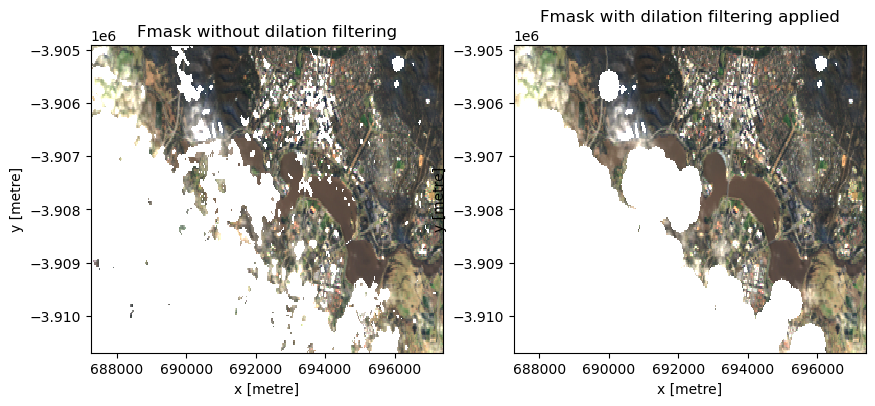

In [9]:
# Plot the data
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ds.isel(time=0).odc.to_rgba(vmin=0, vmax=2000).plot.imshow(ax=ax[0])
ds_filtered.isel(time=0).odc.to_rgba(vmin=0, vmax=2000).plot.imshow(ax=ax[1])
ax[0].set_title("Fmask without dilation filtering")
ax[1].set_title("Fmask with dilation filtering applied");

### Discarding Landsat 7 SLC-off failure data
On [May 31 2003, Landsat 7's Scan Line Corrector (SLC) that compensated for the satellite's forward motion failed](http://usgs.gov/land-resources/nli/landsat/landsat-7), introducing linear data gaps in all subsequent Landsat 7 observations. 
For example, if we plot all our loaded data we can see that some Landsat 7 images contains visible striping:

/env/lib/python3.10/site-packages/odc/geo/_rgba.py:55: RuntimeWarning: invalid value encountered in cast
  return x.astype("uint8")


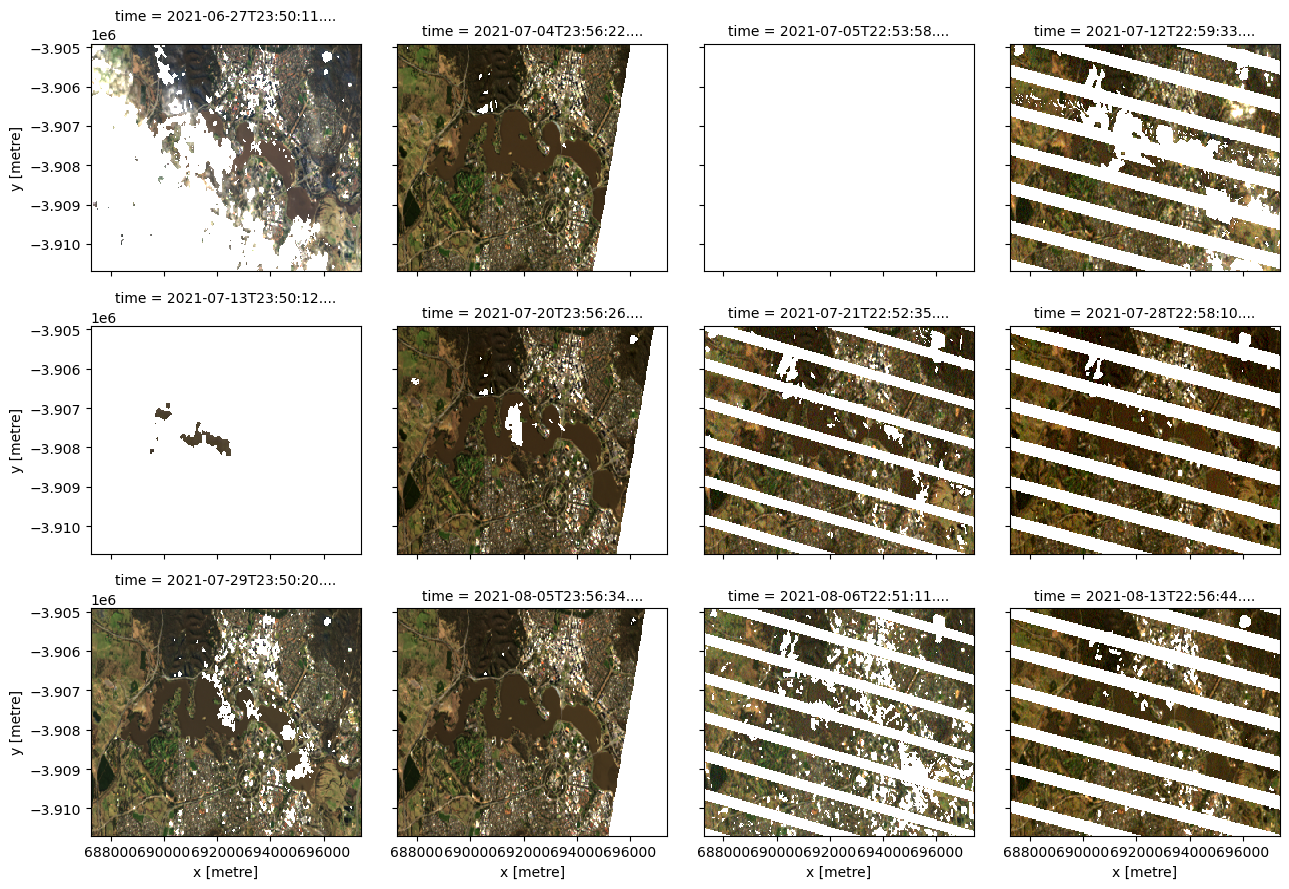

In [10]:
# Plot Landsat data
ds.odc.to_rgba(vmin=0, vmax=2000).plot.imshow(col="time", col_wrap=4)

Although this data still contains valuable information, for some applications (e.g. generating clean composites from multiple images) it can be useful to discard Landsat 7 imagery acquired after the SLC failure.
This data is known as "SLC-off" data.

This can be achieved using `load_ard` using the `ls7_slc_off`. 
By default this is set to `ls7_slc_off=True` which will include all SLC-off data.
Set to `ls7_slc_off=False` to discard this data instead; observe that the function now reports that it is ignoring SLC-off observations:

```
Searching STAC for ... (ignoring SLC-off observations)
 ```


In [11]:
# Load available data after discarding Landsat 7 SLC-off data
ds_ls7 = load_ard(
    dc=catalog,
    products=["ga_ls5t_ard_3", "ga_ls7e_ard_3", "ga_ls8c_ard_3", "ga_ls9c_ard_3"],
    bands=["nbart_green", "nbart_red", "nbart_blue"],
    groupby="solar_day",
    ls7_slc_off=False,
    **query,
)

Loading data with STAC
Searching STAC for ga_ls5t_ard_3, ga_ls7e_ard_3, ga_ls8c_ard_3, ga_ls9c_ard_3 data (ignoring SLC-off observations)
Applying fmask pixel quality/cloud mask
Loading 6 time steps


If we plot our data now, we can see that all of the stripey Landsat 7 scenes have now disappeared:

/env/lib/python3.10/site-packages/odc/geo/_rgba.py:55: RuntimeWarning: invalid value encountered in cast
  return x.astype("uint8")


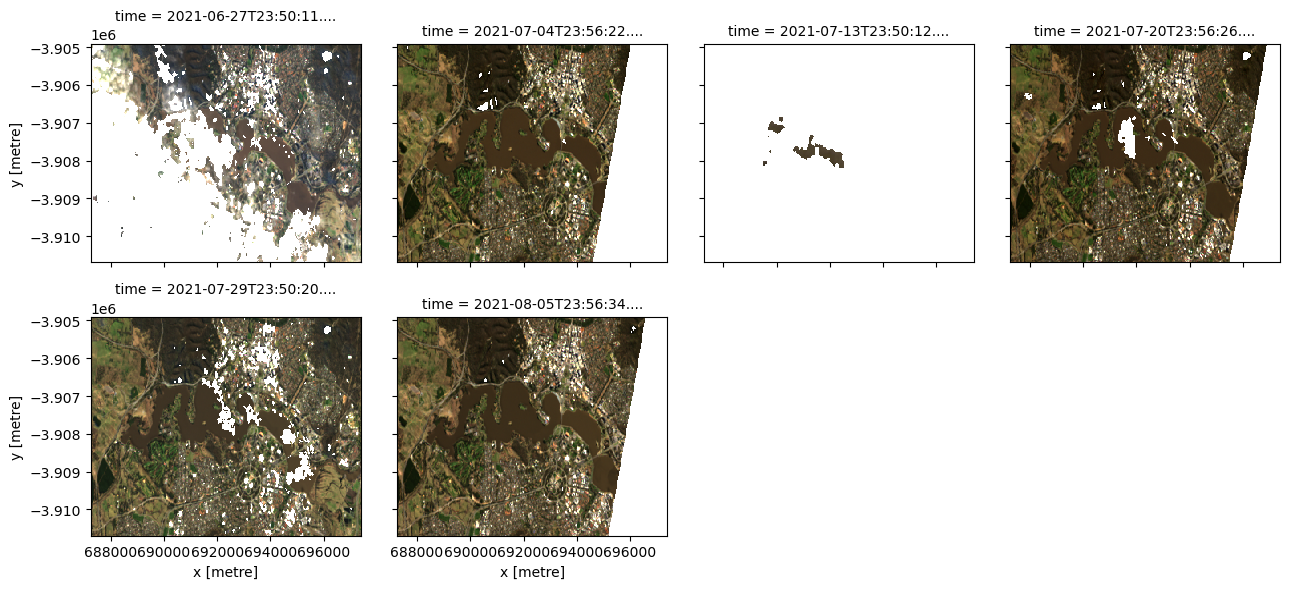

In [12]:
# Plot Landsat data
ds_ls7.odc.to_rgba(vmin=0, vmax=2000).plot.imshow(col="time", col_wrap=4)

### Loading and combining data from multiple Sentinel-2 sensors
Data from the Sentinel-2A, Sentinel-2B and Sentinel-2C satellites can also be loaded using `load_ard`. 
To do this, we need to specify Sentinel-2 products in place of the Landsat products above.

The `query` parameter can be re-used to load Sentinel-2 data for the same location and time period.

In [13]:
# Load available data from both Sentinel 2 satellites
ds_s2 = load_ard(
    dc=catalog,
    products=["ga_s2am_ard_3", "ga_s2bm_ard_3", "ga_s2cm_ard_3"],
    bands=["nbart_green", "nbart_red", "nbart_blue"],
    groupby="solar_day",
    **query,
)

# Print output data
ds_s2

Loading data with STAC
Searching STAC for ga_s2am_ard_3, ga_s2bm_ard_3, ga_s2cm_ard_3 data
Applying fmask pixel quality/cloud mask
Loading 19 time steps


<xarray.Dataset> Size: 133MB
Dimensions:      (time: 19, y: 577, x: 1013)
Coordinates:
  * y            (y) float64 5kB 6.095e+06 6.095e+06 ... 6.089e+06 6.089e+06
  * x            (x) float64 8kB 6.873e+05 6.873e+05 ... 6.974e+05 6.974e+05
    spatial_ref  int32 4B 32755
  * time         (time) datetime64[ns] 152B 2021-06-28T00:06:32.739641 ... 20...
Data variables:
    nbart_green  (time, y, x) float32 44MB 928.0 945.0 971.0 ... 710.0 603.0
    nbart_red    (time, y, x) float32 44MB 974.0 935.0 912.0 ... 804.0 708.0
    nbart_blue   (time, y, x) float32 44MB 685.0 699.0 677.0 ... 507.0 429.0

Similarly to Landsat, cloudy pixels are masked out by default using the `Fmask` cloud mask:

/env/lib/python3.10/site-packages/odc/geo/_rgba.py:55: RuntimeWarning: invalid value encountered in cast
  return x.astype("uint8")


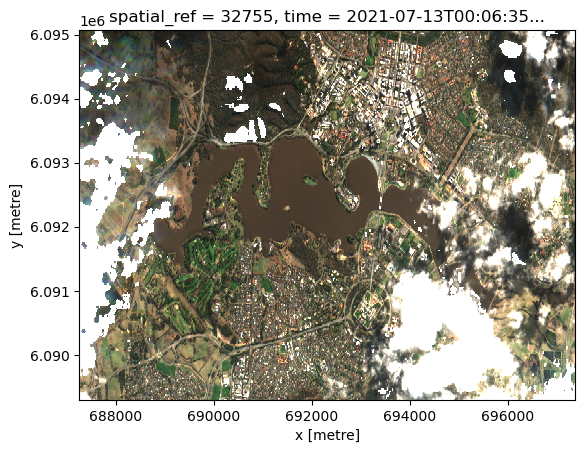

In [14]:
# Plot single observation
ds_s2.isel(time=6).odc.to_rgba(vmin=0, vmax=2000).plot.imshow()

### Cloud masking with `s2cloudless`

When working with Sentinel-2 data, users can continue to use `Fmask` or may try the Sentinel-2 specific cloudmask, `s2cloudless`, [a machine learning cloud mask developed by Sinergise's Sentinel-Hub](https://github.com/sentinel-hub/sentinel2-cloud-detector).

To apply `s2cloudless` to your dataset in place of the default `Fmask`, simply provide `cloud_mask='s2cloudless'` in your `load_ard` function call.

The default for `s2cloudless` will treat `['valid']` pixels as good quality, and set cloudy and nodata pixels to `NaN` (this can be customised using the `s2cloudless_categories` parameter):

Loading data with STAC
Searching STAC for ga_s2am_ard_3, ga_s2bm_ard_3, ga_s2cm_ard_3 data
Applying s2cloudless pixel quality/cloud mask
Loading 19 time steps


/env/lib/python3.10/site-packages/odc/geo/_rgba.py:55: RuntimeWarning: invalid value encountered in cast
  return x.astype("uint8")


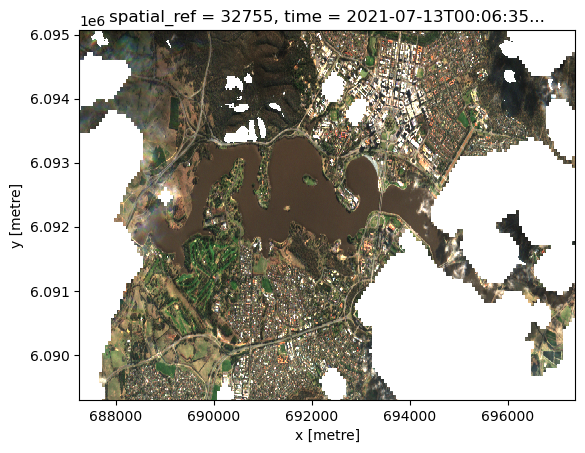

In [15]:
# Load available data from all Sentinel-2 satellites
ds_s2 = load_ard(
    dc=catalog,
    products=["ga_s2am_ard_3", "ga_s2bm_ard_3", "ga_s2cm_ard_3"],
    bands=["nbart_green", "nbart_red", "nbart_blue"],
    groupby="solar_day",
    cloud_mask="s2cloudless",
    **query,
)

# Plot single observation
ds_s2.isel(time=6).odc.to_rgba(vmin=0, vmax=2000).plot.imshow()

We can also easily load and inspect `s2cloudless`'s cloud probability layer that gives the likelihood of a pixel containing cloud.
Because the `load_ard` function applies `Fmask` cloudmasking by default, we can make sure our cloud probability data doesn't get masked by deactivating cloud masking completely using `mask_pixel_quality=False`.

Loading data with STAC
Searching STAC for ga_s2am_ard_3, ga_s2bm_ard_3, ga_s2cm_ard_3 data
Loading 19 time steps


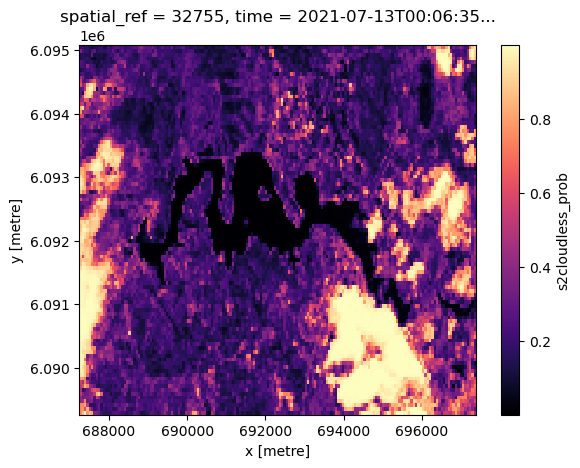

In [16]:
# Load s2cloudless cloud probabilities from all Sentinel-2 satellites
ds_s2 = load_ard(
    dc=catalog,
    products=["ga_s2am_ard_3", "ga_s2bm_ard_3", "ga_s2cm_ard_3"],
    bands=["s2cloudless_prob"],
    groupby="solar_day",
    cloud_mask="s2cloudless",
    mask_pixel_quality=False,
    **query,
)

# Plot single observation
ds_s2.isel(time=6).s2cloudless_prob.plot(cmap="magma");

> **Note:** For more information about cloud masking using `s2cloudless`, refer to the [DEA Sentinel-2 Surface Reflectance notebook.](../DEA_products/DEA_Sentinel2_Surface_Reflectance.ipynb)

## Advanced 

### Filtering data existing metadata
In addition to searching for data by time and location, the `load_ard` function can filter by any searchable metadata fields available for a product using STAC's `filter` extension functionality.
Searchable metadata options can be viewed under the "Metadata document > Properties" heading on a product's dataset page in DEA Explorer; for example:

* https://explorer.dea.ga.gov.au/products/ga_s2bm_ard_3/datasets/e1aa207f-ae0a-4001-b6aa-333e285f6c49#metadata-doc

For instance, we could filter to only the highest quality satellite data available by passing in `eo:dataset_maturity = final`:

In [17]:
# Set up a filter query
filter_query = "eo:dataset_maturity = final"

# Load data with "final" maturity
ds_filtered = load_ard(
    dc=catalog,
    products=["ga_s2am_ard_3", "ga_s2bm_ard_3", "ga_s2cm_ard_3"],
    bands=["nbart_green", "nbart_red", "nbart_blue"],
    groupby="solar_day",
    filter=filter_query,
    **query,
)

Loading data with STAC
Searching STAC for ga_s2am_ard_3, ga_s2bm_ard_3, ga_s2cm_ard_3 data
Applying fmask pixel quality/cloud mask
Loading 19 time steps


Or filter to keep only scenes with high georeferencing accuracy (between 0 and 1 pixel) using `gqa:iterative_mean_xy < 1.0`:

In [18]:
# Set up a filter query
filter_query = "gqa:iterative_mean_xy < 1.0"

# Load data with high geometric quality assessment accuracy
ds_filtered = load_ard(
    dc=catalog,
    products=["ga_s2am_ard_3", "ga_s2bm_ard_3", "ga_s2cm_ard_3"],
    bands=["nbart_green", "nbart_red", "nbart_blue"],
    groupby="solar_day",
    filter=filter_query,
    **query,
)

Loading data with STAC
Searching STAC for ga_s2am_ard_3, ga_s2bm_ard_3, ga_s2cm_ard_3 data
Applying fmask pixel quality/cloud mask
Loading 12 time steps


### Lazy loading with Dask

Rather than load data directly - which can take a long time and large amounts of memory - all datacube data can be lazy loaded using `Dask`.
This can be a very useful approach for when you need to load large amounts of data without crashing your analysis, or if you want to subsequently scale your analysis by distributing tasks in parallel across multiple workers. 
For more information about using Dask, refer to the [Parallel processing with Dask](../Beginners_guide/09_Parallel_processing_with_Dask.ipynb) notebook.

The `load_ard` function can be easily adapted to lazily load data rather than loading it into memory by providing a `chunks` parameter using either the *explicit* or *query* syntax.
The minimum required to lazily load data is `dask_chunks={}`, but chunking can also be performed spatially (e.g. `chunks={'x': 2048, 'y': 2048}`) or by time (e.g. `chunks={'time': 1}`) depending on the analysis being conducted.

First, we can set up a scalable Dask cluster:

In [19]:
client = create_local_dask_cluster()

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/robbi.bishoptaylor@ga.gov.au/proxy/8787/status,
Dashboard: /user/robbi.bishoptaylor@ga.gov.au/proxy/8787/status,Workers: 1
Total threads: 4,Total memory: 14.25 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:37115,Workers: 0
Dashboard: /user/robbi.bishoptaylor@ga.gov.au/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:44017,Total threads: 4
Dashboard: /user/robbi.bishoptaylor@ga.gov.au/proxy/41275/status,Memory: 14.25 GiB
Nanny: tcp://127.0.0.1:45899,


In [20]:
# Lazily load available Sentinel-2 data
ds_dask = load_ard(
    dc=catalog,
    products=["ga_s2am_ard_3", "ga_s2bm_ard_3", "ga_s2cm_ard_3"],
    bands=["nbart_green", "nbart_red", "nbart_blue"],
    chunks={"x": 2048, "y": 2048},
    **query
)

# Print output data
ds_dask

Loading data with STAC
Searching STAC for ga_s2am_ard_3, ga_s2bm_ard_3, ga_s2cm_ard_3 data
Applying fmask pixel quality/cloud mask
Returning 29 time steps as a dask array


<xarray.Dataset> Size: 203MB
Dimensions:      (time: 29, y: 577, x: 1013)
Coordinates:
  * y            (y) float64 5kB 6.095e+06 6.095e+06 ... 6.089e+06 6.089e+06
  * x            (x) float64 8kB 6.873e+05 6.873e+05 ... 6.974e+05 6.974e+05
    spatial_ref  int32 4B 32755
  * time         (time) datetime64[ns] 232B 2021-06-28T00:06:32.739641 ... 20...
Data variables:
    nbart_green  (time, y, x) float32 68MB dask.array<chunksize=(1, 577, 1013), meta=np.ndarray>
    nbart_red    (time, y, x) float32 68MB dask.array<chunksize=(1, 577, 1013), meta=np.ndarray>
    nbart_blue   (time, y, x) float32 68MB dask.array<chunksize=(1, 577, 1013), meta=np.ndarray>

Note that the data loads almost instantaneously, and that each of the arrays listed under `Data variables` are now described as `dask.arrays`.
If we inspect one of these `dask.arrays`, we can view a visualisation of how the data has been broken into small "chunks" of data that can be loaded in parallel:

In [21]:
ds_dask.nbart_red

<xarray.DataArray 'nbart_red' (time: 29, y: 577, x: 1013)> Size: 68MB
dask.array<to_float-4c8a765c, shape=(29, 577, 1013), dtype=float32, chunksize=(1, 577, 1013), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 5kB 6.095e+06 6.095e+06 ... 6.089e+06 6.089e+06
  * x            (x) float64 8kB 6.873e+05 6.873e+05 ... 6.974e+05 6.974e+05
    spatial_ref  int32 4B 32755
  * time         (time) datetime64[ns] 232B 2021-06-28T00:06:32.739641 ... 20...
Attributes:
    nodata:   -999

To load the data into memory, you can run:

In [22]:
ds_dask.compute()

/env/lib/python3.10/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


<xarray.Dataset> Size: 203MB
Dimensions:      (time: 29, y: 577, x: 1013)
Coordinates:
  * y            (y) float64 5kB 6.095e+06 6.095e+06 ... 6.089e+06 6.089e+06
  * x            (x) float64 8kB 6.873e+05 6.873e+05 ... 6.974e+05 6.974e+05
    spatial_ref  int32 4B 32755
  * time         (time) datetime64[ns] 232B 2021-06-28T00:06:32.739641 ... 20...
Data variables:
    nbart_green  (time, y, x) float32 68MB 928.0 945.0 971.0 ... 710.0 603.0
    nbart_red    (time, y, x) float32 68MB 974.0 935.0 912.0 ... 804.0 708.0
    nbart_blue   (time, y, x) float32 68MB 685.0 699.0 677.0 ... 507.0 429.0

***

## Additional information

**License:** The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0). 
Digital Earth Australia data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

**Contact:** If you need assistance, please post a question on the [Open Data Cube Discord chat](https://discord.com/invite/4hhBQVas5U) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).
If you would like to report an issue with this notebook, you can file one on [GitHub](https://github.com/GeoscienceAustralia/dea-notebooks).

**Last tested:**


In [23]:
from datetime import datetime
datetime.today().strftime('%Y-%m-%d')

'2025-12-03'